In [1]:
# Ensure python (*.py) files are reloaded correctly while editing them
%load_ext autoreload
%autoreload 2

Load libs

In [ ]:
import os
import random
from tqdm import tqdm
from PIL import Image
from transformers import pipeline
from huggingface_hub import login
from transformers.image_utils import load_image
from dotenv import load_dotenv
from sklearn.decomposition import PCA
import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter
from typing import List


from utils.DINOv3Wrapper import DINOv3Wrapper
from utils.mvtechDataset import ensure_mvtech_dataset_is_downloaded, get_categories


load_dotenv()
login(token=os.getenv('HF_TOKEN'))

/Users/leventemurgas/Codes/DTU/02456_deep_learning/02456-deep-learning-final-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Load dataset

In [3]:
dataset_path = ensure_mvtech_dataset_is_downloaded(".")

model = DINOv3Wrapper(
    model_name="facebook/dinov3-vits16-pretrain-lvd1689m",
    smaller_edge_size=1024
)

categories = get_categories(dataset_path)

Dataset already exists at ./mvtec_anomaly_detection
Loading facebook/dinov3-vits16-pretrain-lvd1689m on cpu...
Model loaded! Hidden dim: 384, Register tokens: 4, Patch size: 16
Smaller edge size: 1024


In [4]:
TEST_IMAGE_DIR = f'{dataset_path}/toothbrush/test'

image_paths = []

for root, dir, files in os.walk(TEST_IMAGE_DIR):
    for file in files:
        if file.endswith('.png') or file.endswith('.jpg'):
            image_paths.append(os.path.join(root, file))

print(image_paths[:3])

['./mvtec_anomaly_detection/toothbrush/test/defective/002.png', './mvtec_anomaly_detection/toothbrush/test/defective/016.png', './mvtec_anomaly_detection/toothbrush/test/defective/017.png']


Inspect images from dataset

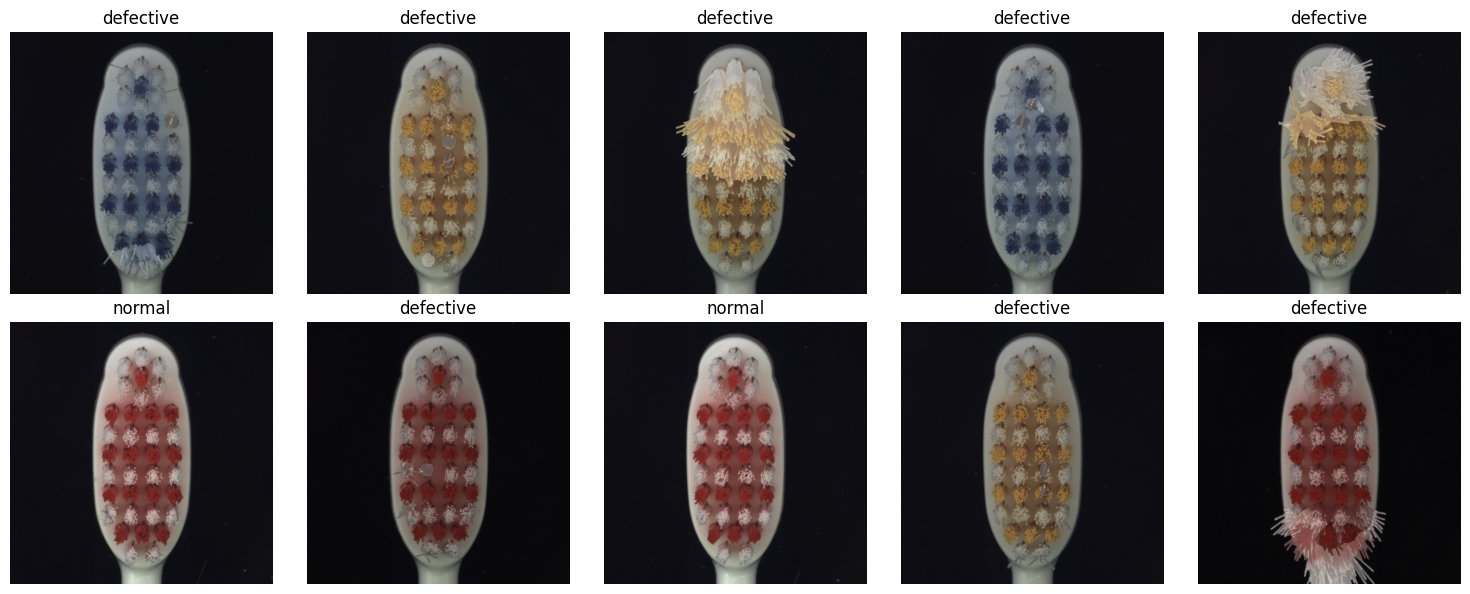

In [5]:
random.shuffle(image_paths)


fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, image_path in zip(axes.flatten(), image_paths[:10]):
    label = 'normal' if 'good' in image_path else 'defective'
    ax.set_title(label)
    img = Image.open(image_path)
    ax.imshow(img)
    ax.axis('off')
    if label == 'defective':
        # load the ground truth mask
        gt_path = image_path.replace('test', 'ground_truth').replace('.png', '_mask.png')
        gt_img = Image.open(gt_path)
        gt_img = gt_img.point(lambda x: 0 if x < 128 else 255, '1')
        ax.imshow(gt_img, alpha=0.2)


plt.tight_layout()
plt.show()

Loading the model

Inference with HF model class

In [9]:
from torchvision import transforms
from transformers import pipeline, AutoModel

MODEL_NAME = "facebook/dinov3-vits16-pretrain-lvd1689m"

feature_extractor = pipeline(
    model=MODEL_NAME,
    task="image-feature-extraction",
)

image = load_image(image_paths[0])

prepped_image_tensor, grid_size = model.prepare_image(image)

print('Prepped image tensor shape:', prepped_image_tensor.shape)  # should be (1, 3, H, W)

# convert pytorch tensor to PIL image again
pil_image = transforms.ToPILImage()(prepped_image_tensor.squeeze())

features = np.array(feature_extractor(pil_image))
print('Inference features shape: (batch_size, tokens, feature_dim)')
print(features.shape)
print('Tokens:  1 class token + 4 register tokens + 196 patch tokens = 201 tokens')

Device set to use mps:0


Prepped image tensor shape: torch.Size([1, 3, 1024, 1024])
Inference features shape: (batch_size, tokens, feature_dim)
(1, 201, 384)
Tokens:  1 class token + 4 register tokens + 196 patch tokens = 201 tokens


In [12]:
model.patch_size

16

AutoModel

In [7]:
from transformers import AutoModel, AutoImageProcessor
tf_model = AutoModel.from_pretrained(MODEL_NAME)
tf_processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

tf_model.eval()
inputs = tf_processor(image, return_tensors="pt")
outputs = tf_model(**inputs)

last_hidden = outputs.last_hidden_state  # (batch, num_tokens, hidden_dim)

# Skip CLS token (1) + register tokens (4) to get patch features
patch_features = last_hidden[:, 1 + 4:, :]

print(patch_features.shape)  # should be (1, 196, feature_dim)

torch.Size([1, 196, 384])


DINOv3Wrapper implementation

In [10]:
wrapper_features = model.extract_features(prepped_image_tensor)

print('Extracted features shape: (tokens, feature_dim)')
print(wrapper_features.shape)

Extracted features shape: (tokens, feature_dim)
(4096, 384)


Experimenting with masking the background

In [10]:
def mask_bg(image, patch_features, threshold_percentile=70, smoothing_sigma=4):
    # Perform PCA
    pca = PCA(n_components=1)
    pca_components = pca.fit_transform(patch_features)  # shape: (196, 1)

    # Reshape to shape of image
    width, height = image.size  # (width, height)
    patch_grid_size = int(np.sqrt(patch_features.shape[0]))  # 14
    pca_map = pca_components.reshape(patch_grid_size, patch_grid_size)

    # Upsample to original image size using PIL
    pca_map_img = Image.fromarray(pca_map.astype(np.float32))
    pca_map_img = pca_map_img.resize((width, height), Image.BILINEAR)
    # apply gaussian smoothing
    pca_map_img = gaussian_filter(np.array(pca_map_img), sigma=smoothing_sigma)
    pca_map = np.array(pca_map_img)

    # Apply threshold
    threshold = np.percentile(pca_map, threshold_percentile)
    bg_mask = pca_map > threshold

    # Apply mask to original image
    masked_image = np.array(image) * bg_mask[..., np.newaxis]
    
    return pca_map, bg_mask, masked_image


In [ ]:

# Extract patch tokens (exclude class token and register tokens)
patch_features = features[0, 5:, :]  # shape: (196, 384)
pca_map, bg_mask, masked_image = mask_bg(image, patch_features)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(pca_map, cmap='viridis')
axes[1].set_title('First PCA Component')
axes[1].axis('off')

axes[2].imshow(bg_mask, cmap='gray')
axes[2].set_title('Thresholded Background Mask')
axes[2].axis('off')

axes[3].imshow(masked_image)
axes[3].set_title('Masked Image')
axes[3].axis('off')

plt.tight_layout()
plt.show()

## Batched Zero-shot setting

The underlying (and necessary) assumption to meaningfully predict anomalies solely based on test samples, is that the majority of samples (or in our case, patches) at test time are from the nominal data distribution (see e.g., Li et al., 2024a).

In [20]:
images = [load_image(path) for path in image_paths]
anomaly_scores = batched_zero_shot_anomaly_detection(images, feature_extractor)
print('Anomaly scores:', anomaly_scores)

100%|██████████| 42/42 [00:01<00:00, 21.57it/s]


All patch features shape: (42, 196, 384)
Anomaly scores: [0.12951247 0.05605719 0.18274368 0.1053149  0.08128045 0.15821714
 0.12129189 0.13448807 0.13345387 0.11853265 0.10174936 0.1396692
 0.05935026 0.11880783 0.05995579 0.05065068 0.09634871 0.06756782
 0.13680059 0.10702656 0.16209306 0.05061907 0.06574791 0.0570387
 0.13026441 0.08773263 0.15971028 0.12734456 0.11363433 0.0594719
 0.13939674 0.0469939  0.13433257 0.11033092 0.12497812 0.09157355
 0.06177963 0.08934032 0.05580956 0.08736928 0.0433678  0.1277029 ]


In [ ]:
OBJECT_TYPES = [
    'bottle',
    'cable',
    'capsule',
    'carpet',
    'grid',
    'hazelnut',
    'leather',
    'metal_nut',
    'pill',
    'screw',
    'tile',
    'toothbrush',
    'transistor',
    'wood',
    'zipper',
]

MASKED_OBJECTS = [ # the classes on which masking makes sense according to AnomalyDINO paper
    'capsule',
    'hazelnut',
    'pill',
    'screw',
    'toothbrush',
]

SELECTED_OBJECTS = ['transistor'] # or None to process all object types
# SELECTED_OBJECTS = None  # or None to process all object types

def main(selected=SELECTED_OBJECTS):
    if selected is None:
        selected = OBJECT_TYPES

    for object_type in tqdm(selected, desc='Processing selected object types', total=len(selected)):
        print(f'Processing object type: {object_type}')
        img_dir = f'{dataset_path}/{object_type}/test'
        image_paths = []
        for root, dir, files in os.walk(img_dir):
            for file in files:
                if file.endswith('.png') or file.endswith('.jpg'):
                    image_paths.append(os.path.join(root, file))

        images = [load_image(path) for path in image_paths]

        if object_type in MASKED_OBJECTS:
            print(f'Applying background masking for {object_type}s')    
            features = np.array([feature_extractor(image) for image in images])
            masked_images = []
            for image, features in zip(images, features):
                patch_features = np.array(features[0, 5:, :])  # shape: (196, 384)
                _, _, masked_image = mask_bg(image, patch_features)
                masked_images.append(Image.fromarray(masked_image))
            images = masked_images

        anomaly_scores = batched_zero_shot_anomaly_detection(images, feature_extractor)

        # save score to /test_scores/{object_type}_scores.npy
        save_dir = f'test_scores/zero_shot/{MODEL_NAME.split("/")[-1]}'
        os.makedirs(save_dir, exist_ok=True)
        score_path = os.path.join(save_dir, f'{object_type}.npy')
        np.save(score_path, anomaly_scores)

main(SELECTED_OBJECTS)

Processing selected object types:   0%|          | 0/1 [00:00<?, ?it/s]

Processing object type: transistor


100%|██████████| 100/100 [00:03<00:00, 31.80it/s]

All patch features shape: (100, 196, 384)
